<a href="https://colab.research.google.com/github/laksamanaap/244107020021-machine-leaning-course-2026-/blob/main/JS04/JS04_TugasLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import dan load dataset

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

df = pd.read_csv("./insurance.csv")

print("\n--- First 5 rows of the DataFrame ---\n")
df.head()

print("\n--- DataFrame Info ---\n")
df.info()

print("\n--- Null values count per column ---\n")
df.isnull().sum()

print("\n--- Descriptive statistics ---\n")
df.describe()


--- First 5 rows of the DataFrame ---


--- DataFrame Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Null values count per column ---


--- Descriptive statistics ---



,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Visualisasi

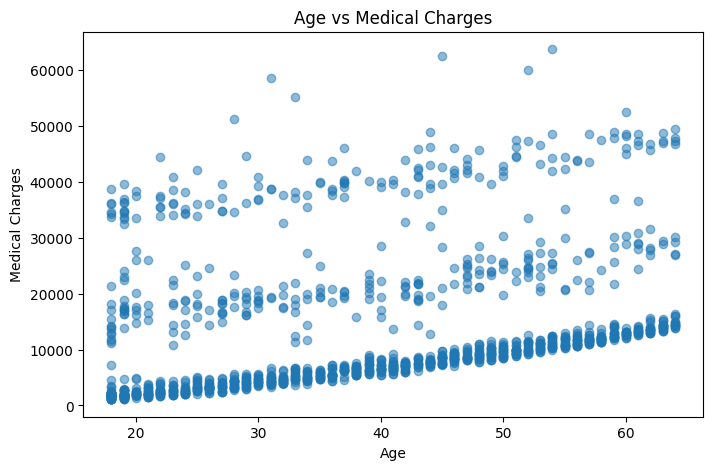

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(df["age"], df["charges"], alpha=0.5)

plt.xlabel("Age")
plt.ylabel("Medical Charges")
plt.title("Age vs Medical Charges")

plt.show()

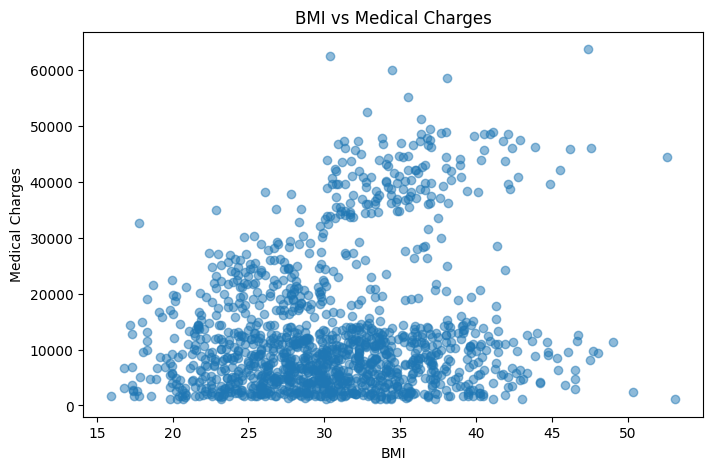

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(df["bmi"], df["charges"], alpha=0.5)

plt.xlabel("BMI")
plt.ylabel("Medical Charges")
plt.title("BMI vs Medical Charges")

plt.show()

<Figure size 800x500 with 0 Axes>

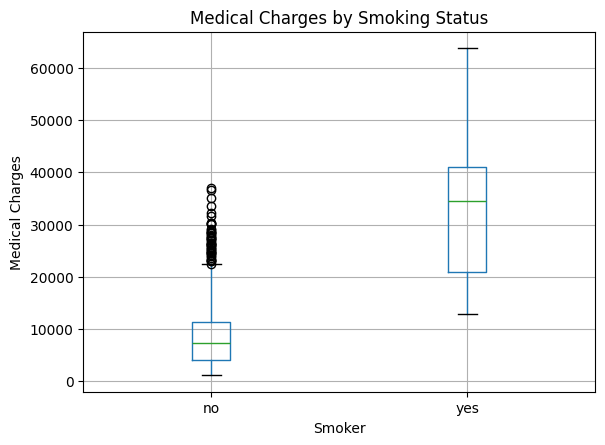

In [7]:
plt.figure(figsize=(8, 5))

df.boxplot(column="charges", by="smoker")

plt.title("Medical Charges by Smoking Status")
plt.suptitle("")
plt.xlabel("Smoker")
plt.ylabel("Medical Charges")

plt.show()

## Tentukan X,Y kemudian train test split

In [9]:
X = df.drop("charges", axis=1)
y = df["charges"]

X.head()
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature scaling encoding + preprocessing

In [11]:
numeric_features = [
    "age",
    "bmi",
    "children"
]

categorical_features = [
    "sex",
    "smoker",
    "region"
]

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

## Multiple Linear Regression

In [13]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

## Evaluasi
r2_linear = r2_score(y_test, y_pred_linear)
mse_linear = mean_squared_error(
    y_test,
    y_pred_linear
)
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

print("Multiple Linear Regression")
print("--------------------------")
print(f"R²  : {r2_linear:.4f}")
print(f"MSE : {mse_linear:.2f}")
print(f"MAE : {mae_linear:.2f}")

Multiple Linear Regression
--------------------------
R²  : 0.7836
MSE : 33596915.85
MAE : 4181.19


## SVR

In [14]:
SVR(kernel="rbf")

svr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVR(
            kernel="rbf"
        ))
    ]
)

svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)

## Evaluasi
r2_svr = r2_score(y_test, y_pred_svr)

mse_svr = mean_squared_error(
    y_test,
    y_pred_svr
)

mae_svr = mean_absolute_error(
    y_test,
    y_pred_svr
)

print("SVR")
print("---")
print(f"R²  : {r2_svr:.4f}")
print(f"MSE : {mse_svr:.2f}")
print(f"MAE : {mae_svr:.2f}")

SVR
---
R²  : -0.0715
MSE : 166348088.63
MAE : 8606.59


## Eksplor Hyperparameter tuning (Grid Search)

In [16]:
param_grid = {
    "model__C": [10, 100, 1000],
    "model__epsilon": [0.1, 0.5, 1.0],
    "model__gamma": [
        "scale",
        0.01,
        0.001
    ]
}

grid_search = GridSearchCV(
    svr_model,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# Fit GridSearchCV to find the best parameters
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

best_svr = grid_search.best_estimator_
y_pred_svr = best_svr.predict(X_test)

## Evaluasi
r2_svr = r2_score(y_test, y_pred_svr)

mse_svr = mean_squared_error(
    y_test,
    y_pred_svr
)

mae_svr = mean_absolute_error(
    y_test,
    y_pred_svr
)

print("SVR - Tuned")
print("------------")
print(f"R²  : {r2_svr:.4f}")
print(f"MSE : {mse_svr:.2f}")
print(f"MAE : {mae_svr:.2f}")

Best Parameters:
{'model__C': 1000, 'model__epsilon': 0.1, 'model__gamma': 'scale'}
SVR - Tuned
------------
R²  : 0.5938
MSE : 63062974.51
MAE : 3433.07


In [17]:
results = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "SVR (Tuned)"
    ],
    "R2": [
        r2_linear,
        r2_svr
    ],
    "MSE": [
        mse_linear,
        mse_svr
    ],
    "MAE": [
        mae_linear,
        mae_svr
    ]
})

results

,Model,R2,MSE,MAE
0,Multiple Linear Regression,0.783593,3.359692e+07,4181.194474
1,SVR (Tuned),0.593794,6.306297e+07,3433.070028


## Visual actual prediction

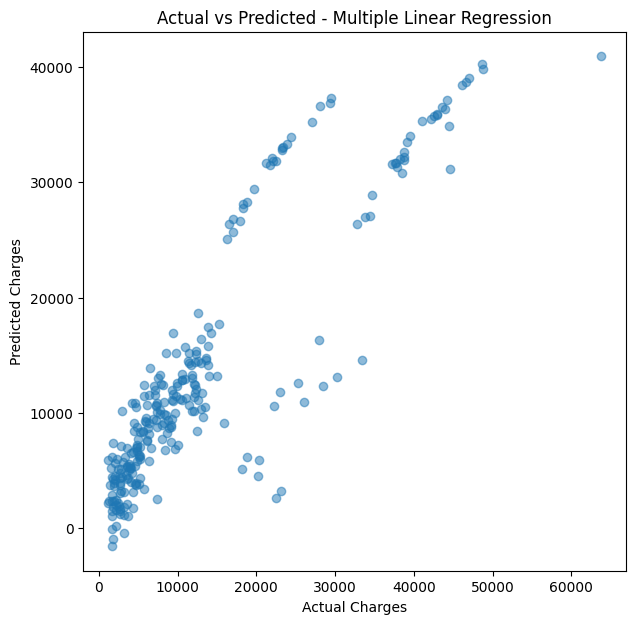

In [18]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.5
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted - Multiple Linear Regression")

plt.show()

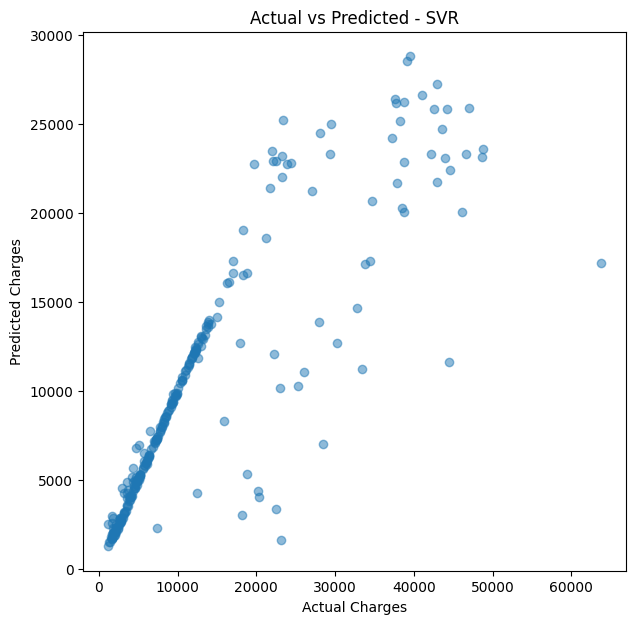

In [19]:
## SVR
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_svr,
    alpha=0.5
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted - SVR")

plt.show()

In [20]:
## Visual Perbandingan Error
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Linear Regression": y_pred_linear,
    "SVR": y_pred_svr
})

comparison.head(10)

,Actual,Linear Regression,SVR
0,9095.06825,8969.550274,9110.532244
1,5272.17580,7068.747443,5307.513388
2,29330.98315,36858.410912,23338.442752
3,9301.89355,9454.678501,9483.003701
4,33750.29180,26973.173457,17120.998893
5,4536.25900,10864.113164,5042.982332
6,2117.33885,170.280841,2531.331515
7,14210.53595,16903.450287,13778.706478
8,3732.62510,1092.430936,4473.104243
9,10264.44210,11218.343184,10449.981537


## Analisis

Pada praktikum ini digunakan Medical Cost Personal Dataset yang berisi 1.338 data. Dataset tersebut memiliki beberapa informasi mengenai seseorang, seperti usia (age), jenis kelamin (sex), BMI (bmi), jumlah anak (children), status perokok (smoker), dan wilayah tempat tinggal (region). Informasi tersebut digunakan untuk memprediksi charges, yaitu biaya medis yang harus dibayarkan oleh seseorang

Sebelum membuat model, dilakukan pengecekan terhadap dataset dan tidak ditemukan data yang kosong. Namun, terdapat beberapa data dalam bentuk kategori seperti sex, smoker, dan region. Karena model machine learning bekerja dengan data numerik, data kategori tersebut diubah menjadi bentuk numerik menggunakan OneHotEncoder. Sementara itu, fitur numerik seperti age, bmi, dan children dilakukan feature scaling menggunakan StandardScaler agar memiliki skala yang lebih seimbang. Dataset kemudian dibagi menjadi 80% data training dan 20% data testing dengan random_state=42

Model pertama yang digunakan adalah Multiple Linear Regression. Model ini dipilih karena terdapat lebih dari satu variabel yang digunakan untuk memprediksi biaya medis. Setelah model dilatih menggunakan data training, model diuji menggunakan data testing dan menghasilkan nilai R² sebesar 0,7836, MSE sebesar 33.596.915,85, dan MAE sebesar 4.181,19

Nilai R² sebesar 0,7836 dapat dipahami bahwa model mampu menjelaskan sekitar 78,36% variasi biaya medis berdasarkan fitur-fitur yang tersedia pada dataset. Sementara itu, nilai MAE sebesar 4.181,19 berarti rata-rata hasil prediksi model memiliki selisih sekitar 4.181 dari biaya medis sebenarnya. Nilai MSE terlihat cukup besar karena perhitungannya menggunakan kuadrat dari error, sehingga kesalahan prediksi yang besar akan memberikan pengaruh yang jauh lebih besar terhadap nilai MSE

Selanjutnya dilakukan percobaan menggunakan Support Vector Regression (SVR) dengan kernel RBF. Pada model ini dilakukan hyperparameter tuning menggunakan GridSearchCV dengan 5-fold cross validation untuk mencari kombinasi parameter yang memberikan hasil validasi terbaik. Dari percobaan yang dilakukan, diperoleh parameter terbaik yaitu C=1000, epsilon=0,1, dan gamma=scale

Jika kedua model dibandingkan, hasilnya menunjukkan bahwa Multiple Linear Regression lebih baik dalam menjelaskan variasi data dan mengurangi error besar, berdasarkan nilai R² dan MSE pada pengujian ini. Di sisi lain, SVR memiliki MAE yang lebih rendah, sehingga rata-rata selisih absolut prediksinya lebih kecil. Perbedaan ini menunjukkan bahwa satu model tidak selalu unggul pada semua metrik evaluasi. Hasil model juga dapat berubah apabila dilakukan perubahan pada pembagian data, preprocessing, kernel, maupun hyperparameter yang digunakan